In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import os
!pip install missingno
!pip install windrose

os.makedirs('../eda', exist_ok=True)


[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
df = pd.read_csv(r"C:\dishu\Cleartrace\data\processed\delhi_aqi_90d.csv")
df['timestamp_hour'] = pd.to_datetime(df['timestamp_hour'])

print(f"Shape: {df.shape}")
print(f"Date range: {df['timestamp_hour'].min()} → {df['timestamp_hour'].max()}")
print(f"Stations: {df['station_name'].nunique()}")

Shape: (82004, 44)
Date range: 2026-04-10 21:00:00 → 2026-07-09 18:00:00
Stations: 38


## Loading the data
- We successfully loaded the data, containing 82,004 rows.
- There are 38 unique AQI stations.
- And the data is for approximately 90 days
 


In [16]:
print(df.dtypes)
print("\nNull counts:")
print(df.isnull().sum())

location_id                          int64
station_name                        object
latitude                           float64
longitude                          float64
provider_name                       object
timestamp_hour              datetime64[ns]
pm25                               float64
pm10                               float64
no2                                float64
co                                 float64
so2                                float64
o3                                 float64
temperature_2m                     float64
relative_humidity_2m                 int64
precipitation                      float64
surface_pressure                   float64
wind_speed_10m                     float64
wind_direction_10m                   int64
no2_ugm3                           float64
so2_ugm3                           float64
co_mgm3                            float64
has_pm25                              bool
has_pm10                              bool
has_no2    

## Findings from the datatypes and null values: 
- wind_direction_10m and relative_humidity_2m needs to be converted to float type
- SO2 has the most missing values and it makes sense as its the pollutant sensor thats least available among all the 6 pollutants we have chosen.
- Rolling averages have more nulls than raw readings 

## Plot 1 : AQI-time series graph

> We want to know the whether all the stations from respective geographic locations of delhi are moving together or not, or showing pattern or not.
- The six we have picked:
- North: Narela
- South: Sri Aurobindo Marg
- East: Anand Vihar
- West: Mundka
- Central: ITO
- Suspect: Chandni Chowk
> We have included chadini chowk as well, as we already suspect it, because of its ~8% valid AQI values.
  

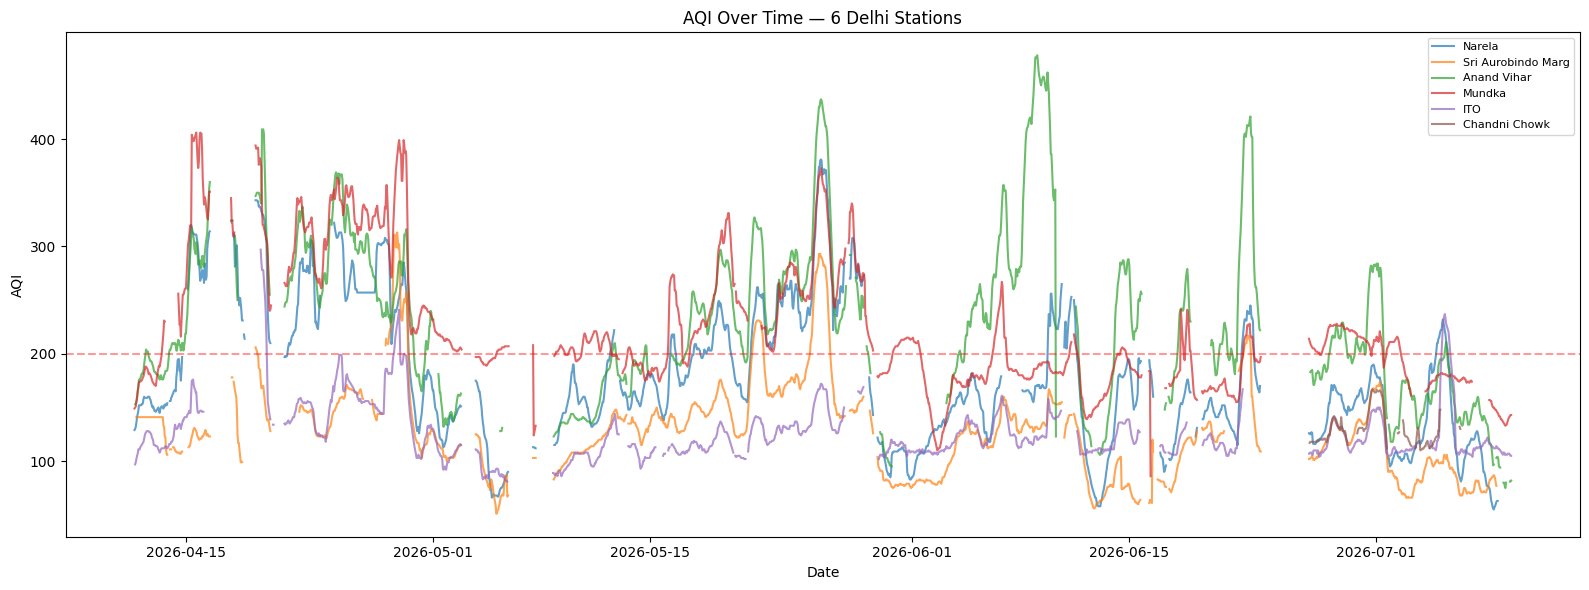

In [4]:
stations_to_plot = [
    'Narela, Delhi - DPCC',
    'Sri Aurobindo Marg, Delhi - DPCC',
    'Anand Vihar, New Delhi - DPCC',
    'Mundka, Delhi - DPCC',
    'ITO, New Delhi - CPCB',
    'Chandni Chowk, Delhi - IITM',
]

fig, ax = plt.subplots(figsize=(16, 6))

for station in stations_to_plot:
    sub = df[df['station_name'] == station].sort_values('timestamp_hour')
    ax.plot(sub['timestamp_hour'], sub['current_aqi'],
            label=station.split(',')[0], alpha=0.7)

ax.set_title('AQI Over Time — 6 Delhi Stations')
ax.set_xlabel('Date')
ax.set_ylabel('AQI')
ax.legend(fontsize=8)
ax.axhline(200, color='red', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig('../eda/plot1_aqi_timeseries.png', dpi=150)
plt.show()

## Findings from the graph: 
- Overall, the AQI stations are moving together city-wide. Although, the magnitude differs in nature.
- Chandni Chowk has only 7.7% valid AQI. Decision: flag as low reliability station during cleaning phase rather than dropping — preserves geographic coverage while reducing its weight in proximity models
- Anand Vihar shows the highest pollution spike among all the stations, which maes complete sense considering its a major bus terminal and highway intersection in East Delhi. The spikes are real. 

## Plot 2 — Missing Value Heatmap

We pivot the data from long format to wide format (rows = timestamps, columns = stations)
so missingno can visualise gap patterns across all 38 stations simultaneously.

- Dark = data present
- White = data missing

We are looking for: random dropout (interpolation), station outages (proxy fill), 
or systematic patterns (maintenance windows).

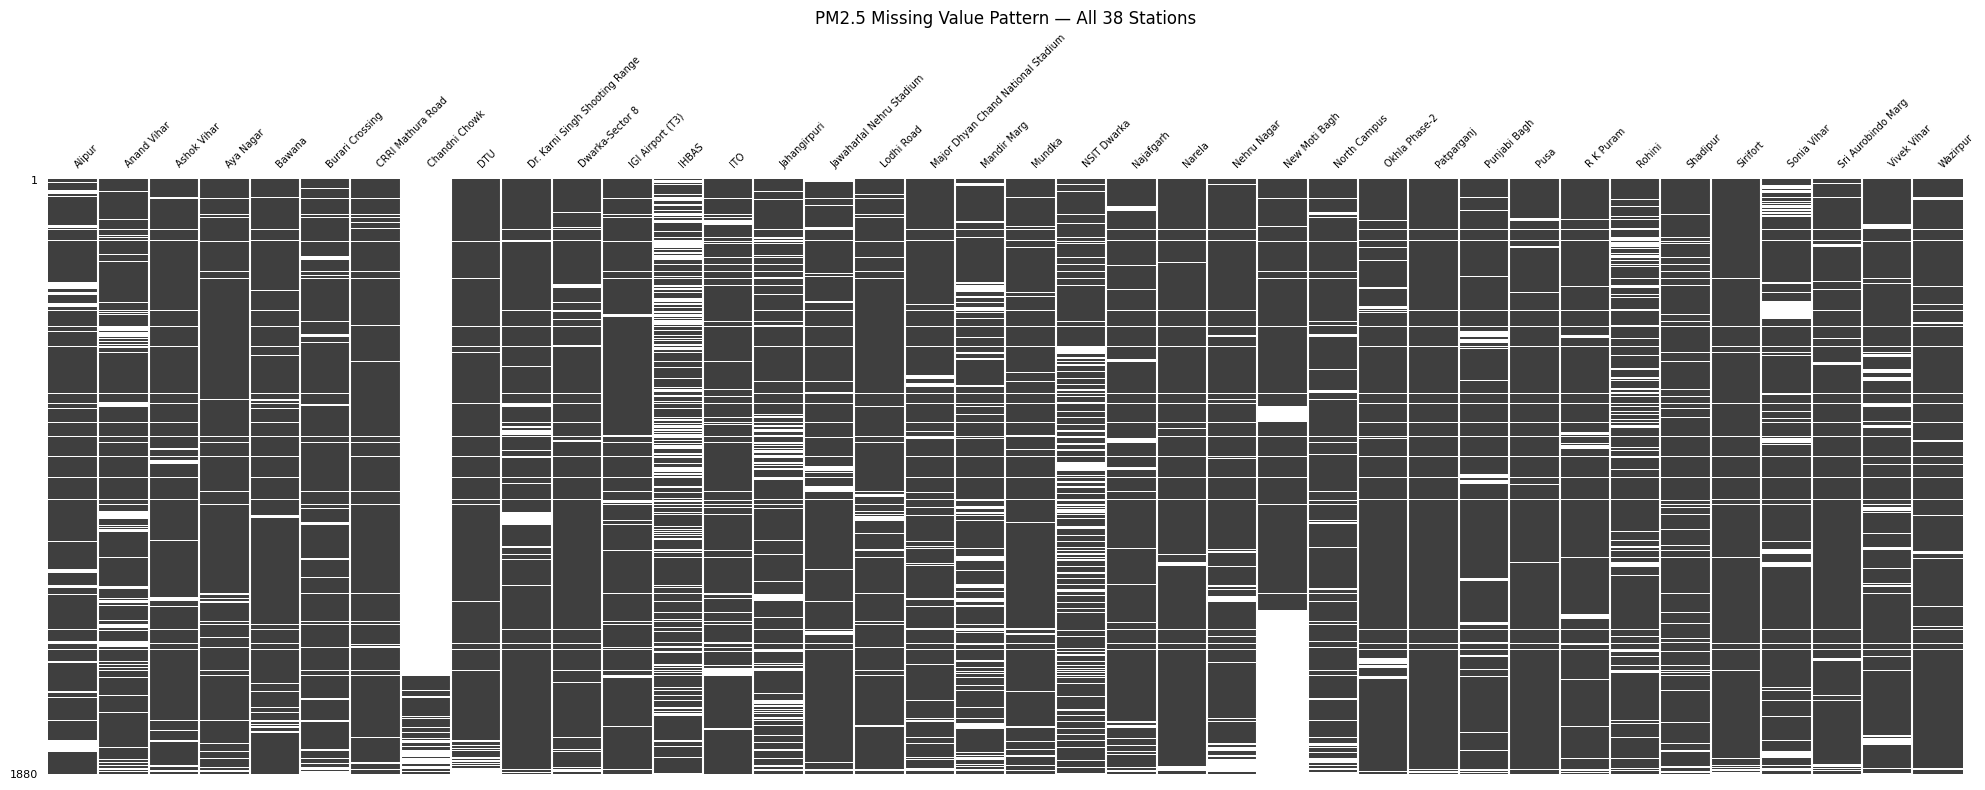

In [11]:
import missingno as msno

pivot = df.pivot_table(
    index='timestamp_hour',
    columns='station_name',
    values='pm25'
)

# Shorten column names for readability
pivot.columns = [c.split(',')[0] for c in pivot.columns]

fig, ax = plt.subplots(figsize=(20, 8))
msno.matrix(pivot, ax=ax, sparkline=False, fontsize=7)
ax.set_title('PM2.5 Missing Value Pattern — All 38 Stations')
plt.tight_layout()
plt.savefig('../eda/plot2_missing_heatmap.png', dpi=150)
plt.show()

## Findings from the graph: 
- Chandni Chowk — almost entirely white = confirms our earlier decision to flag as low reliability
- IHBAS and NSIT Dwarka — long vertical white blocks = extended outages, not random dropout. These need proxy-fill from nearest station, not interpolation
- Scattered white dots across most stations — random dropout = handle with linear interpolation
- No clear horizontal bands — good news, no major city-wide API outages

## Plot 3 — Wind Rose

Polar plot showing wind direction frequency weighted by speed.
We are looking for dominant wind directions in our April-July dataset
to validate that our emission source locations will align with 
actual wind patterns — critical for upwind score calculation on Day 7.


[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


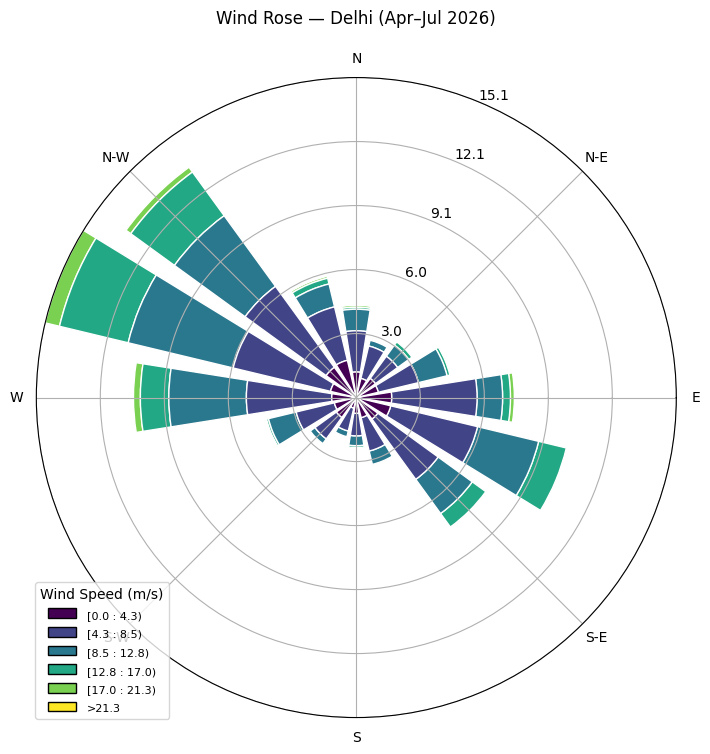

In [15]:
!pip install windrose

from windrose import WindroseAxes

wind_df = df[df['station_name'] == 'ITO, New Delhi - CPCB'].copy()
wind_df = wind_df.dropna(subset=['wind_speed_10m', 'wind_direction_10m'])

fig = plt.figure(figsize=(8, 8))
ax = WindroseAxes.from_ax(fig=fig)
ax.bar(wind_df['wind_direction_10m'], wind_df['wind_speed_10m'],
       normed=True, opening=0.8, edgecolor='white')
ax.set_title('Wind Rose — Delhi (Apr–Jul 2026)', pad=20)
ax.set_legend(title='Wind Speed (m/s)')
plt.savefig('../eda/plot3_wind_rose.png', dpi=150)
plt.show()

## Plot 3 Findings — Wind Rose

- Dominant wind direction: West and Northwest (monsoon onset pattern, Apr–Jul)
- High speed winds (8.5–17 m/s) predominantly from NW direction
- implication for Day 7: emission sources database should prioritize 
  sources to the West and Northwest of sensors — these directions will 
  generate the most meaningful upwind scores in this dataset

## Plot 4 — Wind Direction vs PM2.5

We bin wind direction into 8 compass sectors and compute mean PM2.5 per sector.
This validates our upwind score concept — if wind from specific directions 
consistently brings higher PM2.5, it confirms pollution sources exist in those directions.

If no pattern exists, our attribution approach has a fundamental

C:\Users\saksh\AppData\Local\Temp\ipykernel_22660\3317204360.py:14: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  sector_pm25 = ito.groupby('wind_sector')['pm25'].mean().reindex(labels)


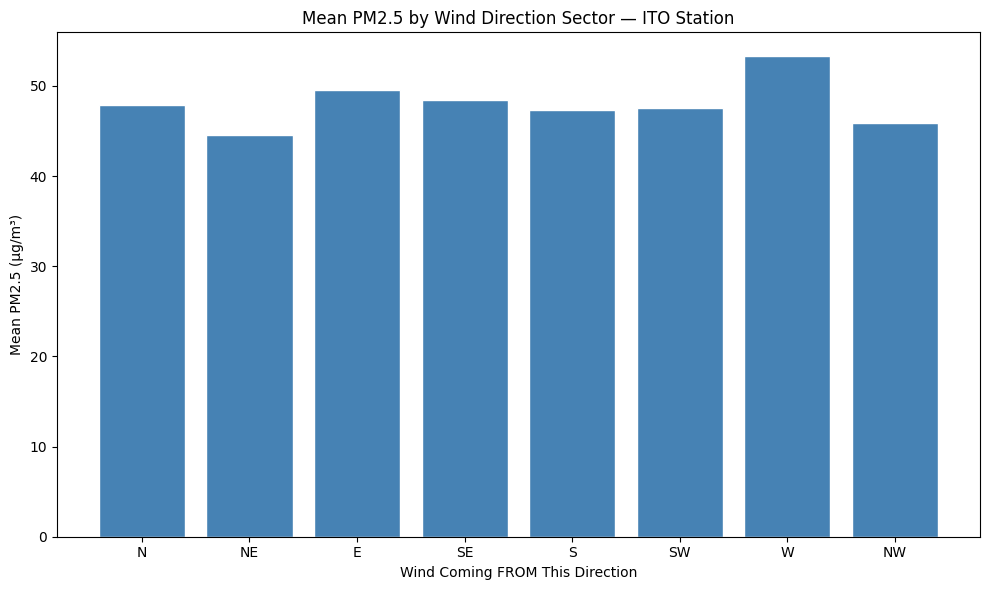

In [14]:
ito = df[df['station_name'] == 'ITO, New Delhi - CPCB'].copy()
ito = ito.dropna(subset=['wind_direction_10m', 'pm25'])

bins = [0, 45, 90, 135, 180, 225, 270, 315, 360]
labels = ['N', 'NE', 'E', 'SE', 'S', 'SW', 'W', 'NW']

ito['wind_sector'] = pd.cut(
    ito['wind_direction_10m'],
    bins=bins,
    labels=labels,
    include_lowest=True
)

sector_pm25 = ito.groupby('wind_sector')['pm25'].mean().reindex(labels)

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(labels, sector_pm25, color='steelblue', edgecolor='white')
ax.set_title('Mean PM2.5 by Wind Direction Sector — ITO Station')
ax.set_xlabel('Wind Coming FROM This Direction')
ax.set_ylabel('Mean PM2.5 (µg/m³)')
plt.tight_layout()
plt.savefig('../eda/plot4_wind_vs_pm25.png', dpi=150)
plt.show()

## Plot 4 Findings — Wind Direction vs PM2.5

- All 8 wind sectors show similar mean PM2.5 (44–53 µg/m³) — narrow range
- West direction shows slightly elevated PM2.5 — consistent with wind rose findings
- Weak directional signal is expected in summer data — strong monsoon winds 
  disperse pollution uniformly across directions
- Upwind score feature remains valid but attribution confidence will be stronger 
  in winter data where winds are calmer and directional patterns more pronounced

## EDA Summary — Key Decisions

### What We Found
- 82,004 rows, 38 stations, 89 days (Apr–Jul 2026, summer dataset)
- ~20% pollutant missingness — random dropout across most stations
- SO2 worst affected at 38% missing
- Chandni Chowk: only 7.7% valid AQI — flagged as low reliability
- IHBAS and NSIT Dwarka: extended vertical outages — need proxy fill
- wind_direction_10m stored as int64 — needs float64 conversion
- Dominant wind: West and Northwest — emission sources database 
  should prioritize these directions

### Decisions Made for cleaning
1. Flag Chandni Chowk as low_reliability — don't drop, reduce weight
2. Short gaps (< 6 hours): linear interpolation
3. Long gaps (> 6 hours): proxy fill from nearest station
4. Convert wind_direction_10m to float64
5. Convert relative_humidity_2m to float64

### Decision 
- Place emission sources to the West and Northwest of sensors
- Upwind score signal is moderate in summer — stronger in winter data

